<a href="https://colab.research.google.com/github/transope/mah_private_public/blob/main/Private_and_Public_Hospital.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Test 1

In [ ]:
import pandas as pd

# Load hospital admissions data
admissions_df = pd.read_csv('/content/M870341-table.csv')
print("Hospital Admissions Data (First 5 rows):")
display(admissions_df.head())

# Load live births data from T9 tab
live_births_df = pd.read_excel('/content/sdb-1h-2026.xlsx', sheet_name='T9')
print("\nLive Births Data (First 15 rows):")
display(live_births_df.head(15))

FileNotFoundError: [Errno 2] No such file or directory: '/content/M870341-table.csv'

In [ ]:
# Find the row with the most non-NaN values to use as the header
valid_rows_counts = admissions_df.notna().sum(axis=1)
header_idx = valid_rows_counts.idxmax()

# Set the new header and drop the metadata rows above it
admissions_clean = admissions_df.iloc[header_idx+1:].copy()
admissions_clean.columns = admissions_df.iloc[header_idx]

# Drop columns and rows that are entirely NaN
admissions_clean = admissions_clean.dropna(axis=1, how='all')
admissions_clean = admissions_clean.dropna(axis=0, how='all')

# Reset index
admissions_clean = admissions_clean.reset_index(drop=True)

print("Cleaned Admissions Data (First 5 rows):")
display(admissions_clean.head())

Cleaned Admissions Data (First 5 rows):


9,Data Series,2026 Jul,2026 Jun,2026 May,2026 Apr,2026 Mar,2026 Feb,2026 Jan,2025 Dec,2025 Nov,...,1987 Oct,1987 Sep,1987 Aug,1987 Jul,1987 Jun,1987 May,1987 Apr,1987 Mar,1987 Feb,1987 Jan
0,Acute Hospitals Admissions,57189,56411,57484,56447,57488,49409,57622,55539,54516,...,na,na,na,na,na,na,na,na,na,na
1,Public,48479,47738,48479,47792,48384,41980,48348,47368,45579,...,na,na,na,na,na,na,na,na,na,na
2,Non-Public,8710,8673,9005,8655,9104,7429,9274,8171,8937,...,na,na,na,na,na,na,na,na,na,na
3,Psychiatric Hospitals Admissions,969,942,969,976,926,817,971,929,927,...,na,na,na,na,na,na,na,na,na,na
4,Public,969,942,969,976,926,817,971,929,927,...,na,na,na,na,na,na,na,na,na,na


In [ ]:
# Clean live births data by dropping completely empty rows and columns
live_births_clean = live_births_df.dropna(axis=1, how='all').dropna(axis=0, how='all')

# Reset the index
live_births_clean = live_births_clean.reset_index(drop=True)

print("Cleaned Live Births Data (First 10 rows):")
display(live_births_clean.head(10))

Cleaned Live Births Data (First 10 rows):


,"Table 9 : Live Births Registered in 1st Half 2026 by Place of Occurrence, \n Ethnic Group of Mother and Sex of Child (Singapore Citizens, Permanent Residents and Foreigners)",Unnamed: 1,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13
0,Place of Occurrence,NaN,All Ethnic Groups,NaN,NaN,Chinese,NaN,Malays,NaN,Indians,NaN,Others,NaN
1,NaN,NaN,Total,Males,Females,Males,Females,Males,Females,Males,Females,Males,Females
2,NaN,NaN,January,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,Public Sector Hospitals,1266,630,636,269,264,223,243,82,81,56,48
4,NaN,Private Sector Hospitals,964,502,462,379,341,21,17,39,28,63,76
5,NaN,Residence,5,2,3,-,-,1,3,-,-,1,-
6,NaN,Other Locations,5,3,2,1,1,1,1,-,-,1,-
7,,Total,2240,1137,1103,649,606,246,264,121,109,121,124
8,NaN,NaN,February,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,Public Sector Hospitals,1196,611,585,258,243,232,221,77,61,44,60


In [ ]:
# Initialize a list to hold our tidy data
tidy_data = []
current_month = None

# Common month names to look for
months = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

for index, row in live_births_clean.iterrows():
    # Convert row to string to easily check for months
    row_str = row.astype(str).str.strip()

    # Check if the row contains a month name
    for month in months:
        if month in row_str.values:
            current_month = month
            break

    # Extract data for Public and Private sectors (located in 'Unnamed: 1')
    place = str(row.get('Unnamed: 1', '')).strip()
    if place in ['Public Sector Hospitals', 'Private Sector Hospitals']:
        # 'Unnamed: 3' holds the Total for All Ethnic Groups based on our previous display
        total = row.get('Unnamed: 3', None)

        tidy_data.append({
            'Month': current_month,
            'Sector': place,
            'Total_Live_Births': total
        })

# Create the tidy DataFrame
live_births_tidy = pd.DataFrame(tidy_data)

if not live_births_tidy.empty:
    # Add year to month (2026 as per the original file name)
    live_births_tidy['Month'] = live_births_tidy['Month'] + ' 2026'

    # Ensure Total_Live_Births is numeric
    live_births_tidy['Total_Live_Births'] = pd.to_numeric(live_births_tidy['Total_Live_Births'], errors='coerce')

    print("Tidy Live Births Data:")
    display(live_births_tidy.head(10))
else:
    print("Error: No data was extracted. Please check the logic and column structures.")

Tidy Live Births Data:


,Month,Sector,Total_Live_Births
0,January 2026,Public Sector Hospitals,1266
1,January 2026,Private Sector Hospitals,964
2,February 2026,Public Sector Hospitals,1196
3,February 2026,Private Sector Hospitals,880
4,March 2026,Public Sector Hospitals,1300
5,March 2026,Private Sector Hospitals,1039
6,April 2026,Public Sector Hospitals,1248
7,April 2026,Private Sector Hospitals,979
8,May 2026,Public Sector Hospitals,1323
9,May 2026,Private Sector Hospitals,1024


In [ ]:
# Extract the relevant rows (index 1 for Public, index 2 for Non-Public under Acute Hospitals)
admissions_subset = admissions_clean.iloc[1:3].copy()

# Rename the first column to 'Sector' for clarity
first_col = admissions_subset.columns[0]
admissions_subset = admissions_subset.rename(columns={first_col: 'Sector'})

# Standardize Sector names to perfectly match the live births data
admissions_subset['Sector'] = admissions_subset['Sector'].astype(str).str.strip().map({
    'Public': 'Public Sector Hospitals',
    'Non-Public': 'Private Sector Hospitals'
})

# Melt the DataFrame to convert date columns into rows
admissions_tidy = pd.melt(admissions_subset, id_vars=['Sector'], var_name='Month', value_name='Total_Admissions')

# Clean 'Month' column and convert to datetime (Format: '2026 Jul')
admissions_tidy['Month'] = pd.to_datetime(admissions_tidy['Month'].astype(str).str.strip(), format='%Y %b', errors='coerce')

# Convert 'Total_Admissions' to numeric, turning 'na' strings into NaN
admissions_tidy['Total_Admissions'] = pd.to_numeric(admissions_tidy['Total_Admissions'], errors='coerce')

# Drop rows with NaN (historical months without data) and reset index
admissions_tidy = admissions_tidy.dropna().reset_index(drop=True)

# Convert live_births_tidy Month to datetime as well for consistency (Format: 'January 2026')
live_births_tidy['Month'] = pd.to_datetime(live_births_tidy['Month'], format='%B %Y', errors='coerce')

print("Tidy Admissions Data (First 10 rows):")
display(admissions_tidy.head(10))

Tidy Admissions Data (First 10 rows):


,Sector,Month,Total_Admissions
0,Public Sector Hospitals,2026-07-01,48479.0
1,Private Sector Hospitals,2026-07-01,8710.0
2,Public Sector Hospitals,2026-06-01,47738.0
3,Private Sector Hospitals,2026-06-01,8673.0
4,Public Sector Hospitals,2026-05-01,48479.0
5,Private Sector Hospitals,2026-05-01,9005.0
6,Public Sector Hospitals,2026-04-01,47792.0
7,Private Sector Hospitals,2026-04-01,8655.0
8,Public Sector Hospitals,2026-03-01,48384.0
9,Private Sector Hospitals,2026-03-01,9104.0


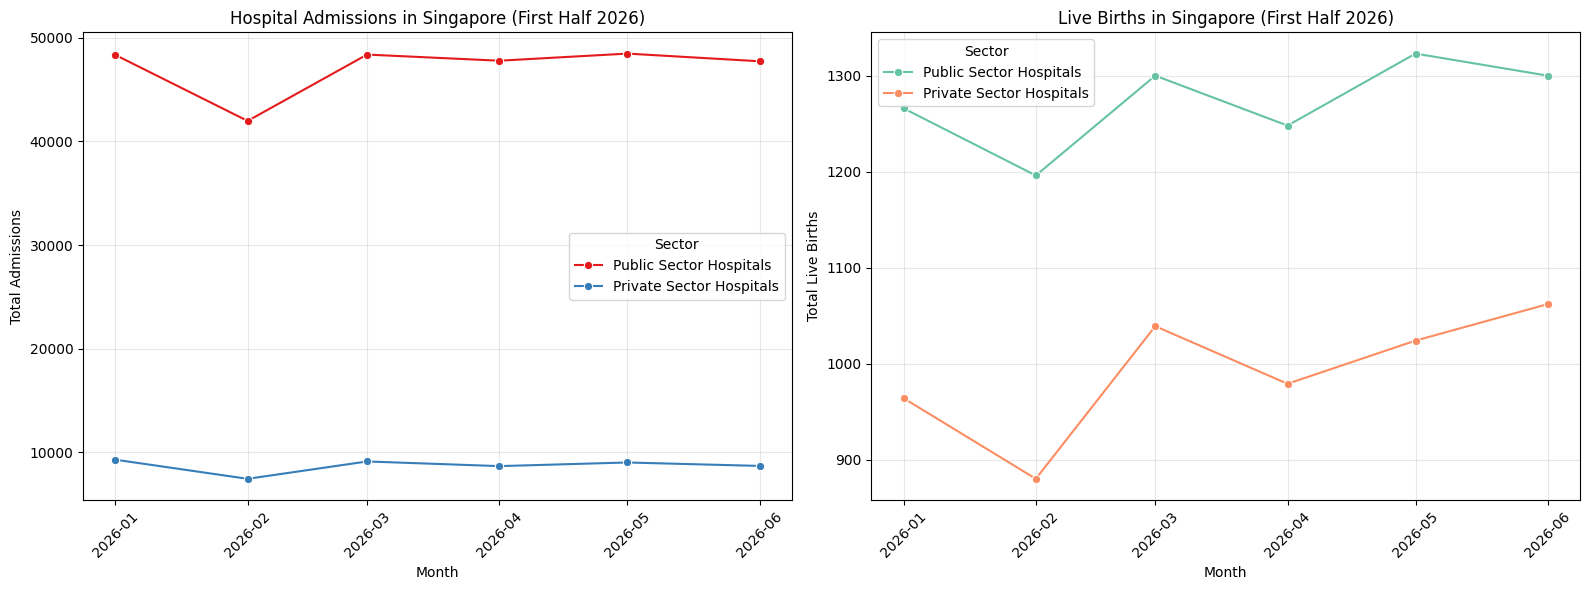


Merged Dashboard Data:


,Sector,Month,Total_Admissions,Total_Live_Births
10,Public Sector Hospitals,2026-01-01,48348.0,1266
11,Private Sector Hospitals,2026-01-01,9274.0,964
8,Public Sector Hospitals,2026-02-01,41980.0,1196
9,Private Sector Hospitals,2026-02-01,7429.0,880
6,Public Sector Hospitals,2026-03-01,48384.0,1300
7,Private Sector Hospitals,2026-03-01,9104.0,1039
4,Public Sector Hospitals,2026-04-01,47792.0,1248
5,Private Sector Hospitals,2026-04-01,8655.0,979
2,Public Sector Hospitals,2026-05-01,48479.0,1323
3,Private Sector Hospitals,2026-05-01,9005.0,1024


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Merge datasets on Month and Sector to get the overlapping periods (Jan-Jun 2026)
dashboard_data = pd.merge(admissions_tidy, live_births_tidy, on=['Month', 'Sector'], how='inner')

# Sort values chronologically for proper plotting
dashboard_data = dashboard_data.sort_values('Month')

# Set up the matplotlib figure (dashboard layout)
plt.figure(figsize=(16, 6))

# Plot 1: Hospital Admissions
plt.subplot(1, 2, 1)
sns.lineplot(data=dashboard_data, x='Month', y='Total_Admissions', hue='Sector', marker='o', palette='Set1')
plt.title('Hospital Admissions in Singapore (First Half 2026)')
plt.ylabel('Total Admissions')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Plot 2: Live Births
plt.subplot(1, 2, 2)
sns.lineplot(data=dashboard_data, x='Month', y='Total_Live_Births', hue='Sector', marker='o', palette='Set2')
plt.title('Live Births in Singapore (First Half 2026)')
plt.ylabel('Total Live Births')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Adjust layout and display
plt.tight_layout()
plt.show()

print("\nMerged Dashboard Data:")
display(dashboard_data)

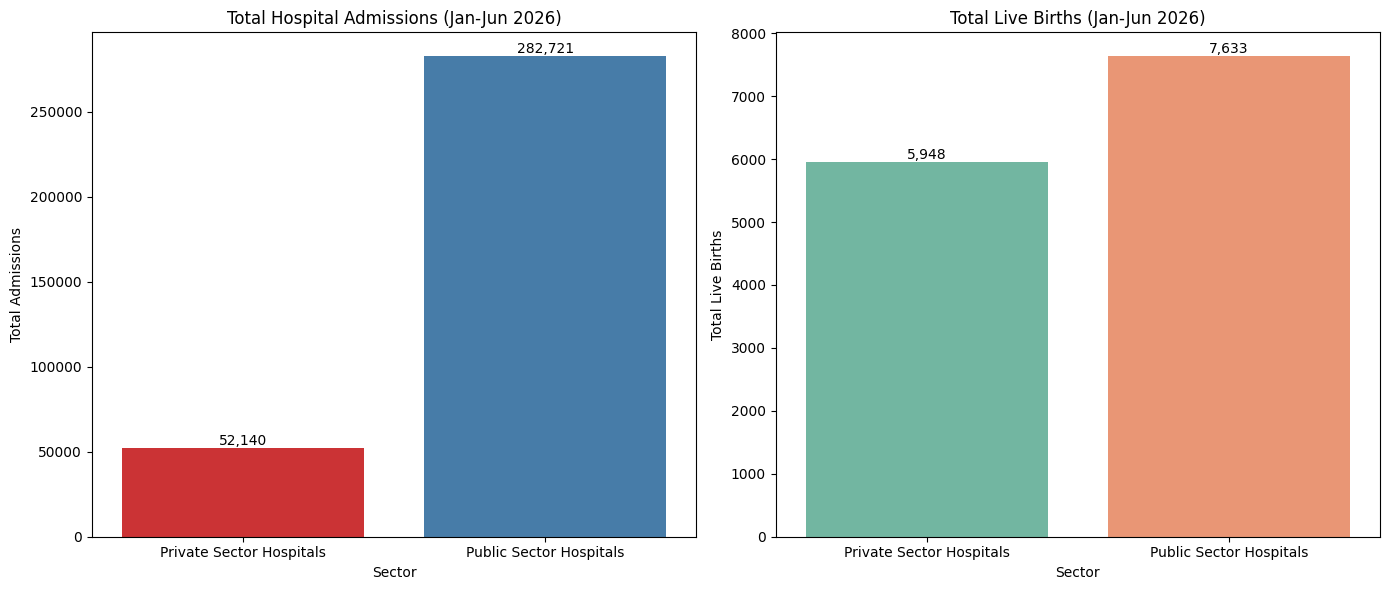

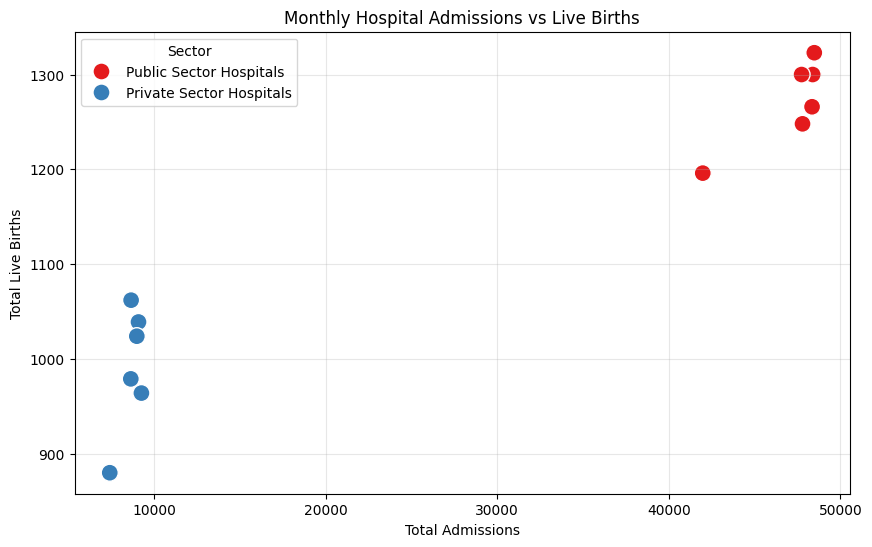

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Aggregate totals by Sector for the first half of 2026
sector_totals = dashboard_data.groupby('Sector').sum(numeric_only=True).reset_index()

# Create a figure with two subplots for the bar charts
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar chart for Total Admissions
sns.barplot(data=sector_totals, x='Sector', y='Total_Admissions', ax=axes[0], hue='Sector', legend=False, palette='Set1')
axes[0].set_title('Total Hospital Admissions (Jan-Jun 2026)')
axes[0].set_ylabel('Total Admissions')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')

# Bar chart for Total Live Births
sns.barplot(data=sector_totals, x='Sector', y='Total_Live_Births', ax=axes[1], hue='Sector', legend=False, palette='Set2')
axes[1].set_title('Total Live Births (Jan-Jun 2026)')
axes[1].set_ylabel('Total Live Births')
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Create a scatter plot to see the relationship between Admissions and Live Births
plt.figure(figsize=(10, 6))
sns.scatterplot(data=dashboard_data, x='Total_Admissions', y='Total_Live_Births', hue='Sector', s=150, palette=['#E41A1C', '#377EB8'])
plt.title('Monthly Hospital Admissions vs Live Births')
plt.xlabel('Total Admissions')
plt.ylabel('Total Live Births')
plt.grid(True, alpha=0.3)
plt.show()

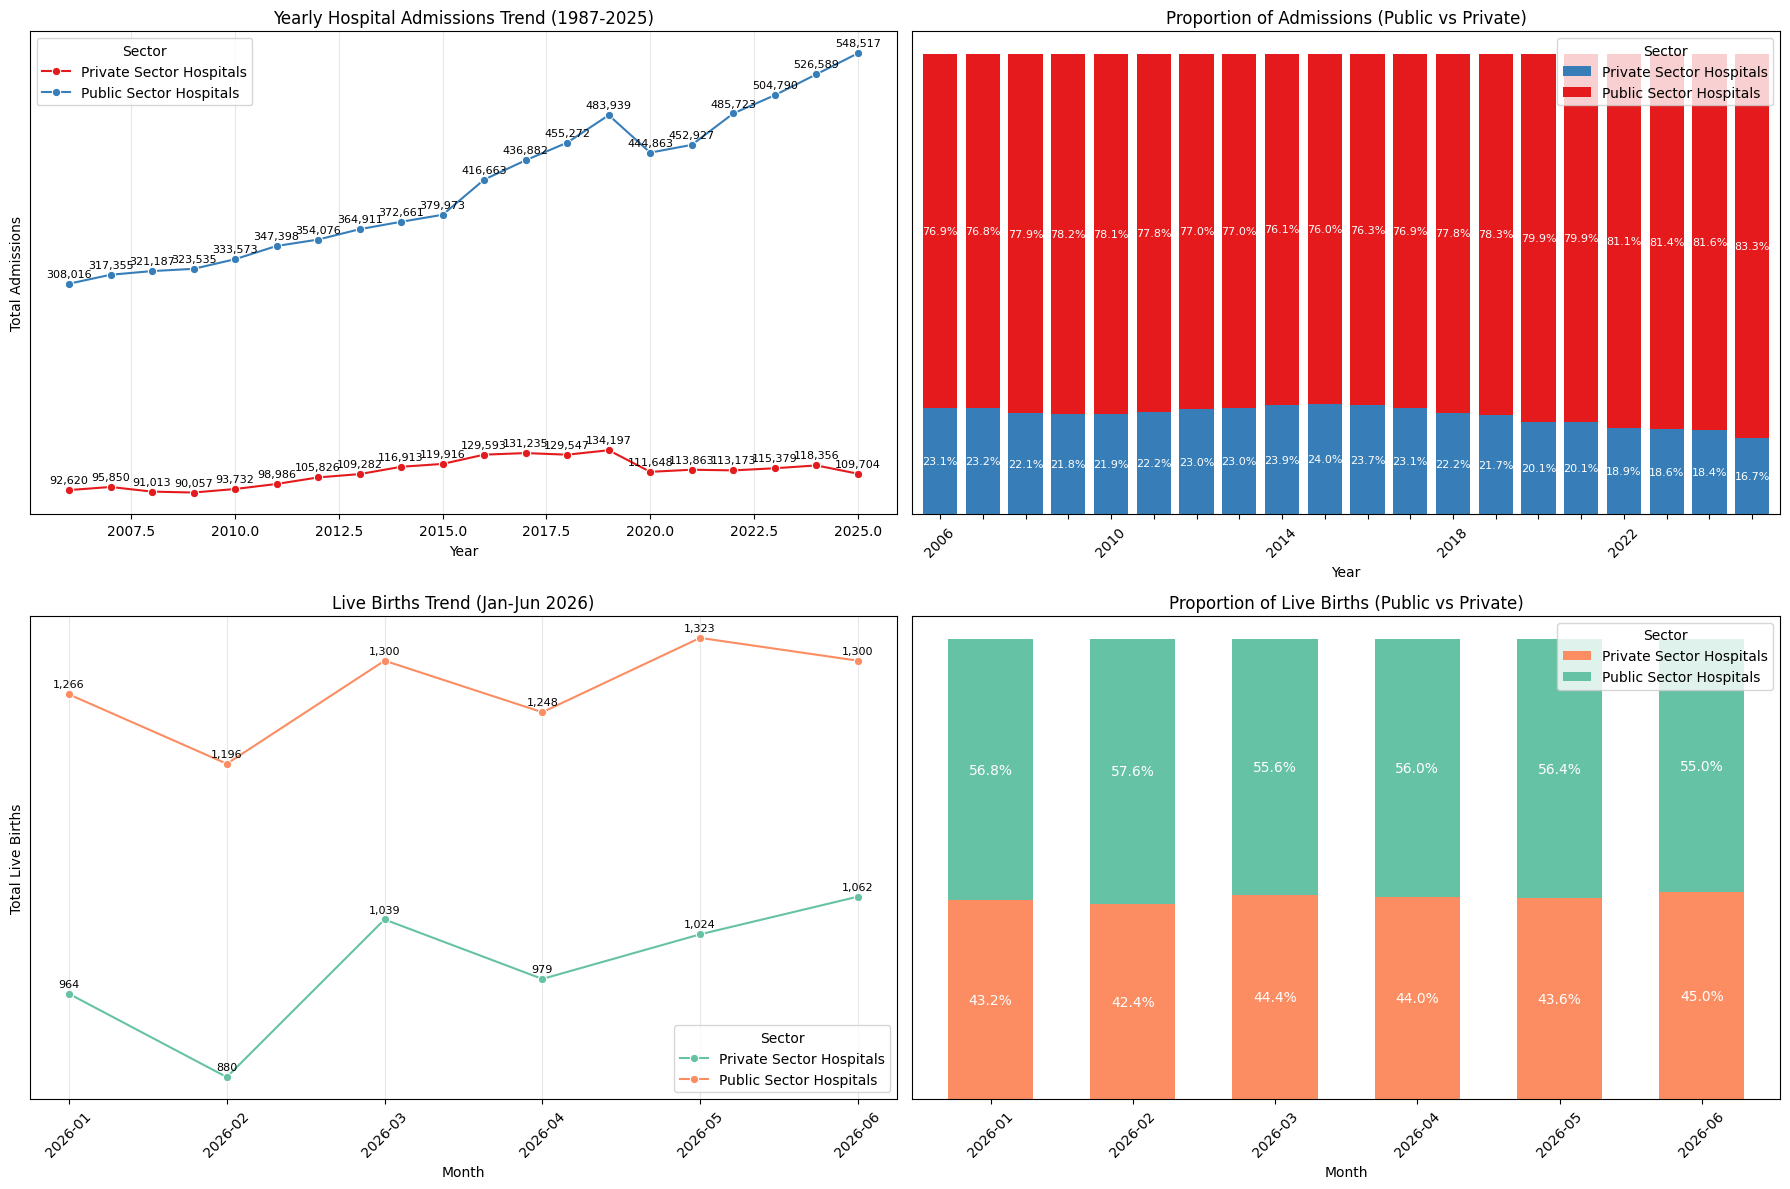

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import pandas as pd

# ==========================================
# 1. Prepare Admissions Data (Yearly Trend)
# ==========================================
admissions_df_viz = admissions_tidy.copy()
admissions_df_viz['Year'] = admissions_df_viz['Month'].dt.year

# Exclude 2026 from yearly trend as it only contains partial data (causes a misleading drop)
admissions_df_viz = admissions_df_viz[admissions_df_viz['Year'] < 2026]

adm_yearly = admissions_df_viz.groupby(['Year', 'Sector'])['Total_Admissions'].sum().reset_index()

# Pivot for proportions (no fillna(0) so missing data stays missing)
adm_pivot = adm_yearly.pivot(index='Year', columns='Sector', values='Total_Admissions')
adm_prop = adm_pivot.div(adm_pivot.sum(axis=1), axis=0) * 100

# ==========================================
# 2. Prepare Live Births Data (Monthly Trend)
# ==========================================
births_df_viz = live_births_tidy.copy()
births_df_viz['Month_Str'] = births_df_viz['Month'].dt.strftime('%Y-%m')
birth_trend = births_df_viz.groupby(['Month_Str', 'Sector'])['Total_Live_Births'].sum().reset_index()

# Pivot for proportions
birth_pivot = birth_trend.pivot(index='Month_Str', columns='Sector', values='Total_Live_Births')
birth_prop = birth_pivot.div(birth_pivot.sum(axis=1), axis=0) * 100

# ==========================================
# 3. Create the Visualizations
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

def add_line_labels(ax, df, x_col, y_col):
    for index, row in df.iterrows():
        if pd.notna(row[y_col]):
            ax.annotate(f"{int(row[y_col]):,}",
                        (row[x_col], row[y_col]),
                        textcoords="offset points",
                        xytext=(0,5),
                        ha='center', fontsize=8)

# --- Plot 1: Admissions Yearly Trend (Line) ---
sns.lineplot(data=adm_yearly, x='Year', y='Total_Admissions', hue='Sector', marker='o', ax=axes[0, 0], palette='Set1')
axes[0, 0].set_title('Yearly Hospital Admissions Trend (1987-2025)')
axes[0, 0].set_ylabel('Total Admissions')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_yticks([]) # Hide y-axis values
add_line_labels(axes[0, 0], adm_yearly, 'Year', 'Total_Admissions')

# --- Plot 2: Admissions Proportions (Stacked Bar) ---
adm_prop.plot(kind='bar', stacked=True, ax=axes[0, 1], color=['#377EB8', '#E41A1C'], width=0.8)
axes[0, 1].set_title('Proportion of Admissions (Public vs Private)')
axes[0, 1].set_ylabel('')
axes[0, 1].set_yticks([]) # Hide y-axis values
for i, label in enumerate(axes[0, 1].get_xticklabels()):
    if i % 4 != 0:
        label.set_visible(False)
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].legend(title='Sector')
for c in axes[0, 1].containers:
    axes[0, 1].bar_label(c, label_type='center', fmt='%.1f%%', color='white', fontsize=8)

# --- Plot 3: Live Births Trend (Line) ---
sns.lineplot(data=birth_trend, x='Month_Str', y='Total_Live_Births', hue='Sector', marker='o', ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('Live Births Trend (Jan-Jun 2026)')
axes[1, 0].set_ylabel('Total Live Births')
axes[1, 0].set_xlabel('Month')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_yticks([]) # Hide y-axis values
add_line_labels(axes[1, 0], birth_trend, 'Month_Str', 'Total_Live_Births')

# --- Plot 4: Live Births Proportions (Stacked Bar) ---
birth_prop.plot(kind='bar', stacked=True, ax=axes[1, 1], color=['#FC8D62', '#66C2A5'], width=0.6)
axes[1, 1].set_title('Proportion of Live Births (Public vs Private)')
axes[1, 1].set_ylabel('')
axes[1, 1].set_xlabel('Month')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].legend(title='Sector')
axes[1, 1].set_yticks([]) # Hide y-axis values
for c in axes[1, 1].containers:
    axes[1, 1].bar_label(c, label_type='center', fmt='%.1f%%', color='white', fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
# Export the cleaned and merged dataset to a CSV file
export_filename = '/content/hospital_admissions_and_live_births_2026.csv'
dashboard_data.to_csv(export_filename, index=False)

print(f"Data successfully exported to: {export_filename}")

Data successfully exported to: /content/hospital_admissions_and_live_births_2026.csv
